In [11]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


In [12]:
class ConversionState(TypedDict):
    celsius: float
    fahrenheit: float

In [13]:
def cel_to_fahr(state: ConversionState) -> ConversionState:
    fahrenheit = state['celsius'] * 9 / 5 + 32
    return {'fahrenheit': fahrenheit}

In [14]:
def fahr_to_cel(state: ConversionState) -> ConversionState:
    celsius = (state['fahrenheit'] - 32) * 5 / 9
    return {'celsius': celsius}

In [15]:
def summary(state: ConversionState) -> ConversionState:
    print(f"{state['celsius']}°C is equal to {state['fahrenheit']}°F")
    return {}

In [16]:
graph = StateGraph(ConversionState)

graph.add_node("cel_to_fahr", cel_to_fahr)
graph.add_node("fahr_to_cel", fahr_to_cel)
graph.add_node("summary", summary)

graph.add_edge(START, "cel_to_fahr")
graph.add_edge(START, "fahr_to_cel")
graph.add_edge("cel_to_fahr", "summary")
graph.add_edge("fahr_to_cel", "summary")
graph.add_edge("summary", END)

workflow = graph.compile()

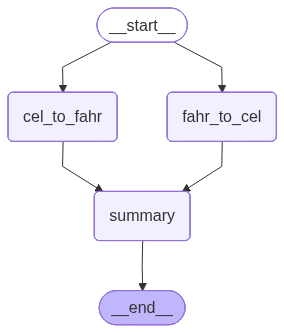

In [17]:
workflow

In [18]:
inital_state = {'celsius': 100.0, 'fahrenheit': 212.0}
result = workflow.invoke(inital_state)
print(result)

100.0°C is equal to 212.0°F
{'celsius': 100.0, 'fahrenheit': 212.0}
